In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [2]:
import os
print("Current Directory:", os.getcwd())
print("Files in Directory:", os.listdir())

Current Directory: U:\TM_DAT_430
Files in Directory: ['.ipynb_checkpoints', 'Analysis_Ready_HR_Data.csv', 'Cleaned_OM_HR_Data.csv', 'HR Attrition Data.csv', 'HR Training Data.csv', 'HRData (1).csv', 'HRData (10).csv', 'HRData (11).csv', 'HRData (12).csv', 'HRData (13).csv', 'HRData (14).csv', 'HRData (2).csv', 'HRData (3).csv', 'HRData (4).csv', 'HRData (5).csv', 'HRData (6).csv', 'HRData (7).csv', 'HRData (8).csv', 'HRData (9).csv', 'Outer_Merged_HR_Data.csv', 'Project_ONE_V1.html', 'Project_ONE_V1.ipynb', 'Project_ONE_V1_0.html', 'Project_Two_V2.ipynb', 'Sentiment_Feb2014.csv', 'Sentiment_March2014.csv']


In [3]:
required_files = [
     "HR Training Data.csv",
    "HRData (1).csv",
    "HRData (2).csv",
        "HRData (3).csv",
    "HRData (4).csv",
        "HRData (5).csv",
    "HRData (6).csv",
        "HRData (7).csv",
    "HRData (8).csv",
    "HRData (9).csv",
    "HRData (10).csv",
        "HRData (11).csv",
    "HRData (12).csv",
        "HRData (13).csv",
    "HRData (14).csv"
]

for file in required_files:
    if os.path.isfile(file):
        print(f"File '{file}' found.")
    else:
        print(f"File '{file}' NOT found.")

File 'HR Training Data.csv' found.
File 'HRData (1).csv' found.
File 'HRData (2).csv' found.
File 'HRData (3).csv' found.
File 'HRData (4).csv' found.
File 'HRData (5).csv' found.
File 'HRData (6).csv' found.
File 'HRData (7).csv' found.
File 'HRData (8).csv' found.
File 'HRData (9).csv' found.
File 'HRData (10).csv' found.
File 'HRData (11).csv' found.
File 'HRData (12).csv' found.
File 'HRData (13).csv' found.
File 'HRData (14).csv' found.


In [4]:
# Sample 'HR Training Data.csv'
try:
    hr_training = pd.read_csv("HR Training Data.csv")
    print(f"File 'HR Training Data.csv' successfully loaded!")
    print(hr_training.head())  # Display the first 5 rows
except FileNotFoundError:
    print("File 'HR Training Data.csv' not found!")

File 'HR Training Data.csv' successfully loaded!
   Age     BusinessTravel  DailyRate              Department  \
0   33      Travel_Rarely        576  Research & Development   
1   56  Travel_Frequently        695         Human Resources   
2   37         Non-Travel       1424                   Sales   
3   20  Travel_Frequently        187                   Sales   
4   33      Travel_Rarely        796  Research & Development   

   DistanceFromHome  JobLevel  HourlyRate  MonthlyRate  MonthlyIncome  \
0                27         1         133        21280          17024   
1                 9         5         147        23520          18816   
2                24         2          89        14240          11392   
3                31         2          91        14560          11648   
4                 5         4         103        16480          13184   

                 JobRole  ...  RelationshipSatisfaction StandardHours  \
0  Laboratory Technician  ...                         

In [5]:
# Sample 'HRData (1).csv'
try:
    hr_training = pd.read_csv("HRData (1).csv")
    print(f"File 'HRData (1).csv' successfully loaded!")
    print(hr_training.head())  # Display the first 5 rows
except FileNotFoundError:
    print("File 'HRData (1).csv' not found!")

File 'HRData (1).csv' successfully loaded!
   Age     BusinessTravel  DailyRate              Department  \
0   20         Non-Travel        870         Human Resources   
1   45         Non-Travel        458         Human Resources   
2   27  Travel_Frequently        871         Human Resources   
3   41         Non-Travel       1237  Research & Development   
4   48         Non-Travel        882         Human Resources   

   DistanceFromHome  Education    EducationField  EmployeeCount  \
0                44          2   Human Resources              1   
1                39          4   Human Resources              1   
2                23          1     Life Sciences              1   
3                44          1   Human Resources              1   
4                24          2  Technical Degree              1   

  EmployeeNumber  EnvironmentSatisfaction  ... StandardHours  \
0     68-5716114                        1  ...            80   
1     09-4992202                        3

In [6]:
# Sample 'HRData (14).csv'
try:
    hr_training = pd.read_csv("HRData (14).csv")
    print(f"File 'HRData (14).csv' successfully loaded!")
    print(hr_training.head())  # Display the first 5 rows
except FileNotFoundError:
    print("File 'HRData (14).csv' not found!")

File 'HRData (14).csv' successfully loaded!
   Age BusinessTravel  DailyRate              Department  DistanceFromHome  \
0   44  Travel_Rarely        872                   Sales                16   
1   44  Travel_Rarely       1471         Human Resources                44   
2   53  Travel_Rarely       1474         Human Resources                31   
3   37  Travel_Rarely        303  Research & Development                 9   
4   21  Travel_Rarely        353                   Sales                 5   

   JobLevel  HourlyRate  MonthlyRate  MonthlyIncome                JobRole  \
0         2         116        18560          14848                Manager   
1         2          71        11360           9088      Research Director   
2         3          34         5440           4352  Laboratory Technician   
3         3          90        14400          11520                Manager   
4         2          33         5280           4224   Sales Representative   

   ...  StandardHo

In [7]:
hr_data_list = [f"HRData ({i}).csv" for i in range(1, 15)] 
combined_data = pd.concat([pd.read_csv(file) for file in hr_data_list], ignore_index=True)
print(f"Combined Data Shape: {combined_data.shape}")


Combined Data Shape: (6040, 35)


In [8]:
# Right Merge combined_data with HR Training Data - Testing
try:
    right_merged_HR_data = pd.merge(hr_training, combined_data, on='EmployeeNumber', how='right')
    print(f"Right Merged HR Data Shape: {right_merged_HR_data.shape}")
except KeyError:
    print("KeyError: Ensure both datasets have a common column like 'EmployeeNumber' for merging.")
    exit()

Right Merged HR Data Shape: (6040, 69)


In [9]:
# Inner Merge combined_data with HR Training Data - still testing
try:
    inner_merged_HR_data = pd.merge(hr_training, combined_data, on='EmployeeNumber', how='inner')
    print(f"Inner Merged HR Data Shape: {inner_merged_HR_data.shape}")
except KeyError:
    print("KeyError: Ensure both datasets have a common column like 'EmployeeNumber' for merging.")
    exit()

Inner Merged HR Data Shape: (2470, 69)


In [10]:
# Outer Merge combined_data with HR Training Data - final merge test
try:
    outer_merged_HR_data = pd.merge(hr_training, combined_data, on='EmployeeNumber', how='outer')
    print(f"Outer Merged HR Data Shape: {outer_merged_HR_data.shape}")
except KeyError:
    print("KeyError: Ensure both datasets have a common column like 'EmployeeNumber' for merging.")
    exit()

Outer Merged HR Data Shape: (6040, 69)


In [11]:
# This is the set I plan to use: Outer Merged HR Data
# outer_merged_HR_data.to_csv("Outer_Merged_HR_Data.csv", index=False)
# print("Outer merged dataset saved as 'Outer_Merged_HR_Data.csv'")

In [12]:
print(outer_merged_HR_data.isnull().sum())  # Checking for missing values by column


Age_x                        3570
BusinessTravel_x             3570
DailyRate_x                  3570
Department_x                 3570
DistanceFromHome_x           3570
                             ... 
YearsAtCompany_y                0
YearsInCurrentRole_y            0
YearsSinceLastPromotion_y       0
YearsWithCurrManager_y          0
Attrition_y                    64
Length: 69, dtype: int64


In [13]:
# Impute missing values in numerical columns with the median
numerical_columns = ['Age_x', 'DistanceFromHome_x', 'DailyRate_x']
outer_merged_HR_data[numerical_columns] = outer_merged_HR_data[numerical_columns].fillna(
    outer_merged_HR_data[numerical_columns].median()
)
print("Missing values in numerical columns handled.")

Missing values in numerical columns handled.


In [14]:
print(outer_merged_HR_data.isnull().sum())  # Checking for missing values by column

Age_x                           0
BusinessTravel_x             3570
DailyRate_x                     0
Department_x                 3570
DistanceFromHome_x              0
                             ... 
YearsAtCompany_y                0
YearsInCurrentRole_y            0
YearsSinceLastPromotion_y       0
YearsWithCurrManager_y          0
Attrition_y                    64
Length: 69, dtype: int64


In [15]:
# Impute missing values in categorical columns with 'Unknown'
categorical_columns = outer_merged_HR_data.select_dtypes(include=['object']).columns
outer_merged_HR_data[categorical_columns] = outer_merged_HR_data[categorical_columns].fillna('Unknown')
print("Missing values in categorical columns handled.")


Missing values in categorical columns handled.


In [16]:
print(outer_merged_HR_data.isnull().sum())  # Checking for missing values by column

Age_x                        0
BusinessTravel_x             0
DailyRate_x                  0
Department_x                 0
DistanceFromHome_x           0
                            ..
YearsAtCompany_y             0
YearsInCurrentRole_y         0
YearsSinceLastPromotion_y    0
YearsWithCurrManager_y       0
Attrition_y                  0
Length: 69, dtype: int64


In [17]:
# Save the cleaned Outer Merged Dataset
# outer_merged_HR_data.to_csv("Cleaned_OM_HR_Data.csv", index=False)
# print("Cleaned dataset saved as 'Cleaned_OM_HR_Data.csv'")

In [18]:
print(outer_merged_HR_data.describe())

             Age_x  DailyRate_x  DistanceFromHome_x   JobLevel_x  \
count  6040.000000  6040.000000         6040.000000  2470.000000   
mean     37.381788   798.955132           12.973675     2.453036   
std       6.813383   261.749890            9.009469     1.337991   
min      18.000000   102.000000            1.000000     1.000000   
25%      37.000000   798.000000           11.000000     1.000000   
50%      37.000000   798.000000           11.000000     2.000000   
75%      37.000000   798.000000           11.000000     3.000000   
max      60.000000  1499.000000           50.000000     5.000000   

       HourlyRate_x  MonthlyRate_x  MonthlyIncome_x  Education_x  \
count   2470.000000    2470.000000      2470.000000  2470.000000   
mean      75.861943   14381.903644      8561.028745     8.169231   
std       29.682906    6532.080139      5237.184499     6.561645   
min       30.000000    2094.000000      1009.000000     1.000000   
25%       52.000000    8800.000000      4224.00

In [19]:
x_columns = [col for col in outer_merged_HR_data.columns if col.endswith('_x')]
y_columns = [col for col in outer_merged_HR_data.columns if col.endswith('_y')]

print(f"Columns with '_x': {x_columns}")
print(f"Columns with '_y': {y_columns}")

Columns with '_x': ['Age_x', 'BusinessTravel_x', 'DailyRate_x', 'Department_x', 'DistanceFromHome_x', 'JobLevel_x', 'HourlyRate_x', 'MonthlyRate_x', 'MonthlyIncome_x', 'JobRole_x', 'Education_x', 'EducationField_x', 'EmployeeCount_x', 'EnvironmentSatisfaction_x', 'Gender_x', 'JobInvolvement_x', 'JobSatisfaction_x', 'MaritalStatus_x', 'NumCompaniesWorked_x', 'Over18_x', 'OverTime_x', 'PercentSalaryHike_x', 'RelationshipSatisfaction_x', 'PerformanceRating_x', 'StandardHours_x', 'StockOptionLevel_x', 'TotalWorkingYears_x', 'TrainingTimesLastYear_x', 'WorkLifeBalance_x', 'YearsAtCompany_x', 'YearsInCurrentRole_x', 'YearsSinceLastPromotion_x', 'YearsWithCurrManager_x', 'Attrition_x']
Columns with '_y': ['Age_y', 'BusinessTravel_y', 'DailyRate_y', 'Department_y', 'DistanceFromHome_y', 'Education_y', 'EducationField_y', 'EmployeeCount_y', 'EnvironmentSatisfaction_y', 'Gender_y', 'HourlyRate_y', 'JobInvolvement_y', 'JobLevel_y', 'JobRole_y', 'JobSatisfaction_y', 'MaritalStatus_y', 'MonthlyInco

In [20]:
# Because I did not do this on my original join. 
for col_x in x_columns:
    col_y = col_x.replace('_x', '_y')  
    if col_y in outer_merged_HR_data.columns:
        # Merge the columns
        new_col_name = col_x.replace('_x', '') 
        outer_merged_HR_data[new_col_name] = outer_merged_HR_data[col_x].combine_first(outer_merged_HR_data[col_y])
        # Drop the original _x and _y columns
        outer_merged_HR_data.drop(columns=[col_x, col_y], inplace=True)


In [21]:
print(outer_merged_HR_data.head())  # Display the first 5 rows
print(outer_merged_HR_data.columns)  # Check remaining columns

  EmployeeNumber   Age BusinessTravel  DailyRate              Department  \
0     68-6826588  44.0  Travel_Rarely      872.0                   Sales   
1     60-4788420  44.0  Travel_Rarely     1471.0         Human Resources   
2     69-8944929  53.0  Travel_Rarely     1474.0         Human Resources   
3     09-6511579  37.0  Travel_Rarely      303.0  Research & Development   
4     73-9729396  21.0  Travel_Rarely      353.0                   Sales   

   DistanceFromHome  JobLevel  HourlyRate MonthlyRate MonthlyIncome  ...  \
0              16.0       2.0       116.0       18560         14848  ...   
1              44.0       2.0        71.0       11360          9088  ...   
2              31.0       3.0        34.0        5440          4352  ...   
3               9.0       3.0        90.0       14400         11520  ...   
4               5.0       2.0        33.0        5280          4224  ...   

  StandardHours StockOptionLevel TotalWorkingYears  TrainingTimesLastYear  \
0        

In [22]:
print(outer_merged_HR_data.describe())

               Age    DailyRate  DistanceFromHome     JobLevel   HourlyRate  \
count  6040.000000  6040.000000       6040.000000  6040.000000  6040.000000   
mean     37.381788   798.955132         12.973675     2.548344    78.217881   
std       6.813383   261.749890          9.009469     1.362928    31.189084   
min      18.000000   102.000000          1.000000     1.000000    30.000000   
25%      37.000000   798.000000         11.000000     1.000000    53.000000   
50%      37.000000   798.000000         11.000000     2.000000    75.000000   
75%      37.000000   798.000000         11.000000     4.000000    97.000000   
max      60.000000  1499.000000         50.000000     5.000000   150.000000   

       EmployeeCount  EnvironmentSatisfaction  JobInvolvement  \
count         6040.0              6040.000000     6040.000000   
mean             1.0                 2.600000        2.621689   
std              0.0                 1.104238        0.946014   
min              1.0        

In [23]:
# Dropping uniform columns for they don't add value in future analysis
uniform_columns = ['EmployeeCount', 'StandardHours']
outer_merged_HR_data.drop(columns=uniform_columns, inplace=True)
print("Dropped uniform columns.")

Dropped uniform columns.


In [24]:
from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max Scaling to numerical columns
scaler = MinMaxScaler()
numerical_columns = outer_merged_HR_data.select_dtypes(include=['float64', 'int64']).columns
outer_merged_HR_data[numerical_columns] = scaler.fit_transform(outer_merged_HR_data[numerical_columns])

print("Numerical columns scaled.")

Numerical columns scaled.


In [25]:
# Apply one-hot encoded categorical columns
categorical_columns = outer_merged_HR_data.select_dtypes(include=['object']).columns
outer_merged_HR_data = pd.get_dummies(outer_merged_HR_data, columns=categorical_columns)

print("Categorical column data encoded.")

Categorical column data encoded.


In [26]:
# Final description and columns
print(outer_merged_HR_data.describe())
print(outer_merged_HR_data.columns)  

               Age    DailyRate  DistanceFromHome     JobLevel   HourlyRate  \
count  6040.000000  6040.000000       6040.000000  6040.000000  6040.000000   
mean      0.461471     0.498894          0.244361     0.387086     0.401816   
std       0.162223     0.187366          0.183867     0.340732     0.259909   
min       0.000000     0.000000          0.000000     0.000000     0.000000   
25%       0.452381     0.498210          0.204082     0.000000     0.191667   
50%       0.452381     0.498210          0.204082     0.250000     0.375000   
75%       0.452381     0.498210          0.204082     0.750000     0.558333   
max       1.000000     1.000000          1.000000     1.000000     1.000000   

       EnvironmentSatisfaction  JobInvolvement  JobSatisfaction  \
count              6040.000000     6040.000000      6040.000000   
mean                  0.533333        0.540563         0.541777   
std                   0.368079        0.315338         0.370806   
min                 

In [27]:
# Save the Final Version of cleaned Outer Merged Dataset
# outer_merged_HR_data.to_csv("Analysis_Ready_HR_Data.csv", index=False)
# print("Final cleaned, scaled and encoded dataset saved as 'Analysis_Ready_HR_Data.csv'")

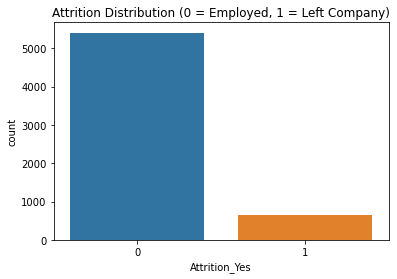

In [28]:
# Attrition Trends:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Attrition_Yes', data=outer_merged_HR_data)
plt.title("Attrition Distribution (0 = Employed, 1 = Left Company)")
plt.show()


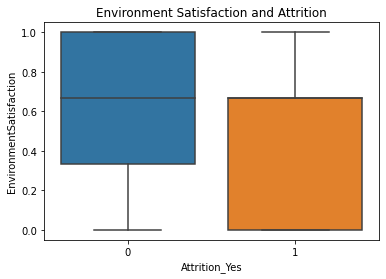

In [29]:
# Environment Satisfaction vs. Attrition:
sns.boxplot(x='Attrition_Yes', y='EnvironmentSatisfaction', data=outer_merged_HR_data)
plt.title("Environment Satisfaction and Attrition")
plt.show()

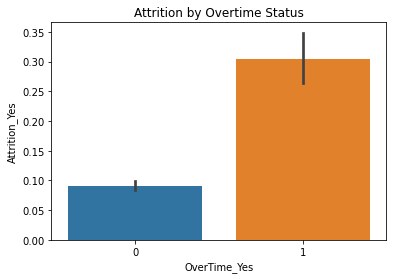

In [30]:
# Relationship Between OverTime_Yes and Attrition_Yes:
sns.barplot(x='OverTime_Yes', y='Attrition_Yes', data=outer_merged_HR_data)
plt.title("Attrition by Overtime Status")
plt.show()

In [31]:
# (Runs in 30min) Correlation Analysis: 
    # Identify features most correlated with Attrition_Yes
corr = outer_merged_HR_data.corr()
attrition_corr = corr['Attrition_Yes'].sort_values(ascending=False)
print(attrition_corr.head(10))  # Top 10 features correlated with attrition

Attrition_Yes                       1.000000
Over18_Yes                          0.427143
OverTime_No                         0.333817
Gender_M                            0.304674
MaritalStatus_Single                0.295619
Gender_F                            0.271827
BusinessTravel_Travel_Frequently    0.264664
DistanceFromHome                    0.264633
Department_Sales                    0.241889
MaritalStatus_Married               0.241205
Name: Attrition_Yes, dtype: float64


In [32]:
# print(attrition_corr.head(20))  # Top 20 features correlated with attrition

In [33]:
# Recheck my data
print(outer_merged_HR_data.head())
print(outer_merged_HR_data.info())


        Age  DailyRate  DistanceFromHome  JobLevel  HourlyRate  \
0  0.619048   0.551181          0.306122      0.25    0.716667   
1  0.619048   0.979957          0.877551      0.25    0.341667   
2  0.833333   0.982105          0.612245      0.50    0.033333   
3  0.452381   0.143880          0.163265      0.50    0.500000   
4  0.071429   0.179671          0.081633      0.25    0.025000   

   EnvironmentSatisfaction  JobInvolvement  JobSatisfaction  \
0                 0.000000        0.666667         0.666667   
1                 0.000000        0.333333         0.666667   
2                 0.333333        1.000000         0.666667   
3                 0.333333        0.333333         1.000000   
4                 0.666667        0.333333         1.000000   

   NumCompaniesWorked  PercentSalaryHike  ...  MaritalStatus_Unknown  \
0            0.333333           1.000000  ...                      0   
1            0.444444           0.000000  ...                      0   
2       

In [45]:
# Selected features from previous Top 10 features correlated with attrition
selected_features = [
    'OverTime_No','BusinessTravel_Travel_Frequently',
    'DistanceFromHome','Department_Sales'
]

# Create feature (X) and target (y) datasets
X = outer_merged_HR_data[selected_features]
y = outer_merged_HR_data['Attrition_Yes']

# Verify shapes
print(f"Features shape: {X.shape}, Target shape: {y.shape}")


Features shape: (6040, 4), Target shape: (6040,)


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))


Logistic Regression Results:
Accuracy: 0.8857615894039735
Confusion Matrix:
 [[1586   24]
 [ 183   19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      1610
           1       0.44      0.09      0.16       202

    accuracy                           0.89      1812
   macro avg       0.67      0.54      0.55      1812
weighted avg       0.85      0.89      0.85      1812



In [47]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Results:
Accuracy: 0.8763796909492274
Confusion Matrix:
 [[1559   51]
 [ 173   29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93      1610
           1       0.36      0.14      0.21       202

    accuracy                           0.88      1812
   macro avg       0.63      0.56      0.57      1812
weighted avg       0.84      0.88      0.85      1812



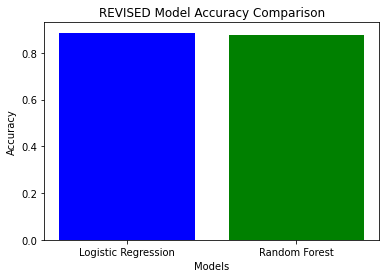

In [50]:
import matplotlib.pyplot as plt

# Accuracy scores
accuracy_scores = [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_rf)]
model_names = ['Logistic Regression', 'Random Forest']

plt.bar(model_names, accuracy_scores, color=['blue', 'green'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('REVISED Model Accuracy Comparison')
plt.show()


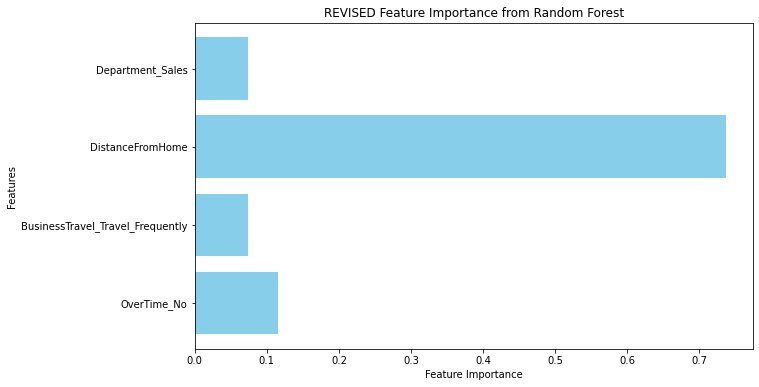

In [51]:
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('REVISED Feature Importance from Random Forest')
plt.show()
